In [35]:
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [36]:
# ============================================================
# BLOQUE 2: Carga del dataset de Nacidos Vivos
# ============================================================

df_raw = pd.read_csv("Registro_de_Nacidos_Vivos.csv", sep=";", on_bad_lines='skip')

print(f"Filas totales: {df_raw.shape[0]:,}")
print(f"Columnas totales: {df_raw.shape[1]}")
print("\nNombre de columnas:")
print(df_raw.columns.tolist())
print("\nPrimeras 3 filas:")
df_raw.head(3)

Filas totales: 4,874,122
Columnas totales: 22

Nombre de columnas:
['FecNac_Año', 'FecNac_Mes', 'PESO_NACIDO', 'TALLA_NACIDO', 'DUR_EMB_PARTO', 'Condicion_Parto', 'sexo_nacido', 'Tipo_Parto', 'Edad_Madre', 'Estado_Civil', 'Nivel_Intrucción_Madre', 'DESC_OCUPACION', 'Num_embar_madre', 'Hijos_vivo_madre', 'Hijos_fallec_madre', 'nacmuer_abort_madre', 'Pais_Madre', 'IdUbigeoInei', 'Ipress', 'Lugar_Nacido', 'Atiende_Parto', 'Financiador_Parto']

Primeras 3 filas:


,FecNac_Año,FecNac_Mes,PESO_NACIDO,TALLA_NACIDO,DUR_EMB_PARTO,Condicion_Parto,sexo_nacido,Tipo_Parto,Edad_Madre,Estado_Civil,...,Num_embar_madre,Hijos_vivo_madre,Hijos_fallec_madre,nacmuer_abort_madre,Pais_Madre,IdUbigeoInei,Ipress,Lugar_Nacido,Atiende_Parto,Financiador_Parto
0,2021,8,3620,52.0,40,EUTOCICO,MASCULINO,UNICO,34,SOLTERO,...,3,2,-1,1,PERU,150121,6211,ESTABLECIMIENTO DE SALUD,OBSTETRA,SIS
1,2021,8,3850,52.0,41,CESAREA,MASCULINO,UNICO,43,SOLTERO,...,>=5,>=5,-1,NINGUNO,PERU,130101,8685,ESTABLECIMIENTO DE SALUD,MEDICO GINECO-OBSTETRA,ESSALUD
2,2021,8,3005,50.0,37,CESAREA,FEMENINO,UNICO,27,SOLTERO,...,3,2,1,NINGUNO,PERU,210112,3251,ESTABLECIMIENTO DE SALUD,MEDICO GINECO-OBSTETRA,SIS


In [37]:
df_ubigeo = pd.read_excel("Ubigeo_de_Peru_INEN.xlsx")

print(f"Filas totales: {df_ubigeo.shape[0]:,}")
print(f"Columnas totales: {df_ubigeo.shape[1]}")
print("\nNombre de columnas:")
print(df_ubigeo.columns.tolist())
print("\nPrimeras 3 filas:")
df_ubigeo.head(3)

Filas totales: 1,874
Columnas totales: 8

Nombre de columnas:
['Ubigeo', 'Distrito', 'Provincia', 'Departamento', 'Poblacion', 'Superficie', 'Y', 'X']

Primeras 3 filas:


,Ubigeo,Distrito,Provincia,Departamento,Poblacion,Superficie,Y,X
0,10101,Chachapoyas,Chachapoyas,Amazonas,29171,153.78,-6.2294,-77.8714
1,10102,Asuncion,Chachapoyas,Amazonas,288,25.71,-6.0317,-77.7122
2,10103,Balsas,Chachapoyas,Amazonas,1644,357.09,-6.8375,-78.0214


In [38]:
# ============================================================
# BLOQUE 3: Limpieza y Validación de Datos
# ============================================================

df = df_raw.copy()

print("="*60)
print("ESTADO INICIAL")
print("="*60)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

# ── 3.1 Duplicados ──────────────────────────────────────────
duplicados = df.duplicated().sum()
df = df.drop_duplicates()
print(f"\n  Duplicados eliminados: {duplicados:,}")

# ── 3.2 Valores inválidos en variables numéricas ─────────────
# Según diccionario: -1 = ignorado, >=5 como texto
numericas_especiales = ['Num_embar_madre', 'Hijos_vivo_madre',
                         'Hijos_fallec_madre', 'nacmuer_abort_madre']

for col in numericas_especiales:
    if col in df.columns:
        # Convertir >=5 a 5
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace('>=5', '5')
        # Convertir -1 e IGNORADO a NaN
        df[col] = df[col].replace({'-1': np.nan, 'IGNORADO': np.nan,
                                    'NINGUNO': '0'})
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"  Variables numéricas especiales normalizadas")

# ── 3.3 IGNORADO → NaN en variables categóricas ──────────────
categoricas = ['Condicion_Parto', 'sexo_nacido', 'Tipo_Parto',
               'Estado_Civil', 'Nivel_Intrucción_Madre',
               'Lugar_Nacido', 'Atiende_Parto', 'Financiador_Parto',
               'Pais_Madre']

for col in categoricas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'IGNORADO': np.nan, 'nan': np.nan,
                                    '-1': np.nan})

print(f"  Variables categóricas: IGNORADO → NaN")

# ── 3.4 Eliminar Hijos_fallec_madre por alto % nulos ─────────
nulos_fallec = df['Hijos_fallec_madre'].isna().mean() * 100
print(f"\n% nulos en Hijos_fallec_madre: {nulos_fallec:.2f}%")
df = df.drop(columns=['Hijos_fallec_madre'])
print(f"  Columna Hijos_fallec_madre eliminada")

# ── 3.5 Eliminar registros sin Ubigeo válido ─────────────────
df['IdUbigeoInei'] = pd.to_numeric(df['IdUbigeoInei'], errors='coerce')
sin_ubigeo = df['IdUbigeoInei'].isna().sum()
df = df.dropna(subset=['IdUbigeoInei'])
df['IdUbigeoInei'] = df['IdUbigeoInei'].astype(int)
print(f"  Registros sin Ubigeo eliminados: {sin_ubigeo:,}")

# ── 3.6 Eliminar registros sin año o mes ─────────────────────
sin_fecha = df[['FecNac_Año', 'FecNac_Mes']].isna().any(axis=1).sum()
df = df.dropna(subset=['FecNac_Año', 'FecNac_Mes'])
df['FecNac_Año'] = df['FecNac_Año'].astype(int)
df['FecNac_Mes'] = df['FecNac_Mes'].astype(int)
print(f"  Registros sin fecha eliminados: {sin_fecha:,}")

print(f"\n{'='*60}")
print(f"ESTADO FINAL TRAS LIMPIEZA")
print(f"{'='*60}")
print(f"Filas restantes: {df.shape[0]:,}")
print(f"Columnas restantes: {df.shape[1]}")
print(f"\nNulos por columna relevante:")
cols_relevantes = ['FecNac_Año', 'FecNac_Mes', 'Edad_Madre',
                   'Estado_Civil', 'Nivel_Intrucción_Madre',
                   'IdUbigeoInei', 'Financiador_Parto', 'Atiende_Parto']
for col in cols_relevantes:
    if col in df.columns:
        pct = df[col].isna().mean()*100
        print(f"  {col}: {pct:.2f}%")

ESTADO INICIAL
Filas: 4,874,122
Columnas: 22

  Duplicados eliminados: 975
  Variables numéricas especiales normalizadas
  Variables categóricas: IGNORADO → NaN

% nulos en Hijos_fallec_madre: 96.97%
  Columna Hijos_fallec_madre eliminada
  Registros sin Ubigeo eliminados: 0
  Registros sin fecha eliminados: 0

ESTADO FINAL TRAS LIMPIEZA
Filas restantes: 4,873,147
Columnas restantes: 21

Nulos por columna relevante:
  FecNac_Año: 0.00%
  FecNac_Mes: 0.00%
  Edad_Madre: 0.00%
  Estado_Civil: 4.15%
  Nivel_Intrucción_Madre: 0.05%
  IdUbigeoInei: 0.00%
  Financiador_Parto: 0.79%
  Atiende_Parto: 0.09%


In [39]:
# ============================================================
# BLOQUE 4: Carga y preparación del Ubigeo
# ============================================================

df_ubigeo = pd.read_excel("Ubigeo_de_Peru_INEN.xlsx")

# Asegurar formato correcto del código Ubigeo (6 dígitos)
df_ubigeo['Ubigeo'] = df_ubigeo['Ubigeo'].astype(str).str.zfill(6)

# Extraer códigos departamental y provincial
df_ubigeo['cod_dep']  = df_ubigeo['Ubigeo'].str[:2]
df_ubigeo['cod_prov'] = df_ubigeo['Ubigeo'].str[:4]

# Tabla de mapeo departamental
df_dep = df_ubigeo.groupby('cod_dep').agg(
    Departamento=('Departamento', 'first'),
    Poblacion_dep=('Poblacion', 'sum')
).reset_index()

# Tabla de mapeo provincial
df_prov = df_ubigeo.groupby('cod_prov').agg(
    Provincia=('Provincia',    'first'),
    Departamento=('Departamento', 'first'),
    cod_dep=('cod_dep',       'first'),
    Poblacion_prov=('Poblacion', 'sum')
).reset_index()

print(f"✓ Ubigeo cargado: {df_ubigeo.shape[0]:,} distritos")
print(f"✓ Departamentos únicos: {df_dep.shape[0]}")
print(f"✓ Provincias únicas:    {df_prov.shape[0]}")
print(f"\nEjemplo departamentos:")
print(df_dep.head(5).to_string())
print(f"\nEjemplo provincias:")
print(df_prov.head(5).to_string())

✓ Ubigeo cargado: 1,874 distritos
✓ Departamentos únicos: 25
✓ Provincias únicas:    196

Ejemplo departamentos:
  cod_dep Departamento  Poblacion_dep
0      01     Amazonas         425832
1      02       Ancash        1166180
2      03     Apurimac         464583
3      04     Arequipa        1329801
4      05     Ayacucho         711058

Ejemplo provincias:
  cod_prov     Provincia Departamento cod_dep  Poblacion_prov
0     0101   Chachapoyas     Amazonas      01           55591
1     0102         Bagua     Amazonas      01           77213
2     0103       Bongara     Amazonas      01           34406
3     0104  Condorcanqui     Amazonas      01           55819
4     0105          Luya     Amazonas      01           52048


In [40]:
# ============================================================
# BLOQUE 5: Integración geográfica y creación de trimestre
# ============================================================

# Formatear Ubigeo del dataset CNV a 6 dígitos
df['IdUbigeoInei'] = df['IdUbigeoInei'].astype(str).str.zfill(6)

# Extraer códigos geográficos
df['cod_dep']  = df['IdUbigeoInei'].str[:2]
df['cod_prov'] = df['IdUbigeoInei'].str[:4]

# Crear variable trimestre
def mes_a_trimestre(mes):
    if mes in [1, 2, 3]:    return 1
    elif mes in [4, 5, 6]:  return 2
    elif mes in [7, 8, 9]:  return 3
    else:                    return 4

df['Trimestre'] = df['FecNac_Mes'].apply(mes_a_trimestre)

# Filtrar a partir de 2018 (rango de la población INEI 2018-2026)
df = df[df['FecNac_Año'] >= 2018].copy()
print(f" Filtrado desde 2018 (población INEI disponible): {df.shape[0]:,} filas")

# Unir con nombres geográficos
df = df.merge(df_dep[['cod_dep', 'Departamento']],
              on='cod_dep', how='left')
df = df.merge(df_prov[['cod_prov', 'Provincia']],
              on='cod_prov', how='left')

# Eliminar registros sin departamento asignado
sin_dep = df['Departamento'].isna().sum()
df = df.dropna(subset=['Departamento'])
print(f" Registros sin departamento eliminados: {sin_dep:,}")
print(f" Filas tras integración: {df.shape[0]:,}")
print(f"\nDistribución por trimestre:")
print(df['Trimestre'].value_counts().sort_index())
print(f"\nDepartamentos únicos: {df['Departamento'].nunique()}")
print(f"Provincias únicas:    {df['Provincia'].nunique()}")

 Filtrado desde 2018 (población INEI disponible): 3,515,987 filas
 Registros sin departamento eliminados: 6,329
 Filas tras integración: 3,509,658

Distribución por trimestre:
Trimestre
1    906729
2    899029
3    890839
4    813061
Name: count, dtype: int64

Departamentos únicos: 25
Provincias únicas:    195


In [42]:
# ============================================================
# BLOQUE 6: Selección y agrupación de variables categóricas
# ============================================================

# ── 6.1 Estado Civil → 4 grupos ─────────────────────────────
def agrupar_estado_civil(val):
    if pd.isna(val): return np.nan
    val = str(val).upper().strip()
    if val in ['CASADO', 'CASADA']:           return 'CASADO'
    elif val in ['CONVIVIENTE']:              return 'CONVIVIENTE'
    elif val in ['SOLTERO', 'SOLTERA']:       return 'SOLTERO'
    else:                                      return 'OTRO'

df['Estado_Civil_Grp'] = df['Estado_Civil'].apply(agrupar_estado_civil)

# ── 6.2 Nivel Educativo → 4 grupos ──────────────────────────
def agrupar_educacion(val):
    if pd.isna(val): return np.nan
    val = str(val).upper().strip()
    if 'SUPERIOR' in val:                     return 'SUPERIOR'
    elif 'SECUNDARIA' in val:                 return 'SECUNDARIA'
    elif 'PRIMARIA' in val:                   return 'PRIMARIA'
    else:                                      return 'SIN_INSTRUCCION'

df['Educacion_Grp'] = df['Nivel_Intrucción_Madre'].apply(agrupar_educacion)

# ── 6.3 Financiador → 4 grupos ──────────────────────────────
def agrupar_financiador(val):
    if pd.isna(val): return np.nan
    val = str(val).upper().strip()
    if val == 'SIS':                          return 'SIS'
    elif val in ['ESSALUD', 'ESALUD']:        return 'ESSALUD'
    elif val == 'PARTICULAR':                 return 'PARTICULAR'
    else:                                      return 'OTRO'

df['Financiador_Grp'] = df['Financiador_Parto'].apply(agrupar_financiador)

# ── 6.4 Lugar de nacimiento → 3 grupos ──────────────────────
def agrupar_lugar(val):
    if pd.isna(val): return np.nan
    val = str(val).upper().strip()
    if 'ESTABLECIMIENTO' in val:              return 'ESTABLECIMIENTO'
    elif val == 'DOMICILIO':                  return 'DOMICILIO'
    else:                                      return 'OTRO'

df['Lugar_Grp'] = df['Lugar_Nacido'].apply(agrupar_lugar)

print("✓ Variables categóricas agrupadas")
print(f"\nEstado Civil:\n{df['Estado_Civil_Grp'].value_counts()}")
print(f"\nEducación:\n{df['Educacion_Grp'].value_counts()}")
print(f"\nFinanciador:\n{df['Financiador_Grp'].value_counts()}")
print(f"\nLugar:\n{df['Lugar_Grp'].value_counts()}")

✓ Variables categóricas agrupadas

Estado Civil:
Estado_Civil_Grp
SOLTERO        2942768
CASADO          330557
CONVIVIENTE      73377
OTRO             16716
Name: count, dtype: int64

Educación:
Educacion_Grp
SECUNDARIA         1803199
SUPERIOR           1222760
PRIMARIA            453787
SIN_INSTRUCCION      27410
Name: count, dtype: int64

Financiador:
Financiador_Grp
SIS           2453141
ESSALUD        605108
OTRO           212014
PARTICULAR     206706
Name: count, dtype: int64

Lugar:
Lugar_Grp
ESTABLECIMIENTO    3431603
DOMICILIO            49761
OTRO                 28090
Name: count, dtype: int64


In [43]:
# ============================================================
# BLOQUE 7: Carga de poblaciones trimestrales REALES (INEI)
# ============================================================
# Fuente: INEI - "Perú: Población Total Proyectada al 30 de junio
# de cada año, según Departamento, Provincia y Distrito, 2018-2026".
# La población trimestral se obtuvo por interpolación lineal entre
# años consecutivos reales (ver script de preparación de población).

#  Cargar población trimestral por departamento y provincia
df_pop_dep  = pd.read_csv("poblacion_dep_trimestral_INEI.csv",
                          dtype={'cod_dep': str})
df_pop_prov = pd.read_csv("poblacion_prov_trimestral_INEI.csv",
                          dtype={'cod_prov': str})

# Renombrar 'Anho' → 'FecNac_Año' para que calce con los paneles
df_pop_dep  = df_pop_dep.rename(columns={'Anho': 'FecNac_Año'})
df_pop_prov = df_pop_prov.rename(columns={'Anho': 'FecNac_Año'})

# Verificación rápida de columnas (deben calzar con Bloque 9)
print("✓ Poblaciones trimestrales REALES cargadas (INEI 2018-2026)")
print(f"  Departamental: {df_pop_dep.shape[0]:,} filas")
print(f"  Provincial:    {df_pop_prov.shape[0]:,} filas")
print(f"\n  Columnas df_pop_dep:  {df_pop_dep.columns.tolist()}")
print(f"  Columnas df_pop_prov: {df_pop_prov.columns.tolist()}")

print(f"\nEjemplo población departamental (Lima, cod_dep='15'):")
print(df_pop_dep[df_pop_dep['cod_dep']=='15'].head(8).to_string(index=False))

✓ Poblaciones trimestrales REALES cargadas (INEI 2018-2026)
  Departamental: 1,296 filas
  Provincial:    7,920 filas

  Columnas df_pop_dep:  ['cod_dep', 'FecNac_Año', 'Trimestre', 'Poblacion_dep_trim']
  Columnas df_pop_prov: ['cod_prov', 'FecNac_Año', 'Trimestre', 'Poblacion_prov_trim']

Ejemplo población departamental (Lima, cod_dep='15'):
cod_dep  FecNac_Año  Trimestre  Poblacion_dep_trim
     15        2018          1          10180641.0
     15        2018          2          10239515.5
     15        2018          3          10298390.0
     15        2018          4          10357264.5
     15        2019          1          10416139.0
     15        2019          2          10469221.8
     15        2019          3          10522304.5
     15        2019          4          10575387.2


In [44]:
# ============================================================
# BLOQUE 8: Agregación Espacio-Temporal
# ============================================================

# Variables a agregar por grupo (año, trimestre, unidad geográfica)
# Definimos las funciones de agregación

def agregar_panel(df, nivel_geo, col_geo):
    """
    nivel_geo: 'departamental' o 'provincial'
    col_geo:   'cod_dep' o 'cod_prov'
    """
    grp = [col_geo, 'FecNac_Año', 'Trimestre']

    agg_dict = {
        # Conteo de nacimientos (variable objetivo base)
        'FecNac_Mes': 'count',

        # Variables de edad materna
        'Edad_Madre': ['mean',
                       lambda x: (x < 18).mean() * 100,   # % adolescentes
                       lambda x: (x > 35).mean() * 100],  # % >35 años

        # Variables reproductivas
        'Num_embar_madre':   'mean',
        'Hijos_vivo_madre':  'mean',
        'nacmuer_abort_madre': 'mean',

        # Proporciones de estado civil
        'Estado_Civil_Grp': [
            lambda x: (x == 'CASADO').mean()      * 100,
            lambda x: (x == 'CONVIVIENTE').mean() * 100,
            lambda x: (x == 'SOLTERO').mean()     * 100,
        ],

        # Proporciones de educación
        'Educacion_Grp': [
            lambda x: (x == 'SUPERIOR').mean()        * 100,
            lambda x: (x == 'SECUNDARIA').mean()      * 100,
            lambda x: (x == 'PRIMARIA').mean()        * 100,
            lambda x: (x == 'SIN_INSTRUCCION').mean() * 100,
        ],

        # Proporciones de financiador
        'Financiador_Grp': [
            lambda x: (x == 'SIS').mean()        * 100,
            lambda x: (x == 'ESSALUD').mean()    * 100,
            lambda x: (x == 'PARTICULAR').mean() * 100,
        ],

        # Proporción lugar de nacimiento
        'Lugar_Grp': [
            lambda x: (x == 'ESTABLECIMIENTO').mean() * 100,
            lambda x: (x == 'DOMICILIO').mean()       * 100,
        ],
    }

    panel = df.groupby(grp).agg(agg_dict).reset_index()

    # Renombrar columnas
    panel.columns = [col_geo, 'FecNac_Año', 'Trimestre',
                     'Nacimientos',
                     'Edad_Media', 'Pct_Adolescentes', 'Pct_Mayor35',
                     'Prom_Embarazos', 'Prom_HijosVivos', 'Prom_Abortos',
                     'Pct_Casado', 'Pct_Conviviente', 'Pct_Soltero',
                     'Pct_Educ_Superior', 'Pct_Educ_Secundaria',
                     'Pct_Educ_Primaria', 'Pct_Educ_SinInstruccion',
                     'Pct_SIS', 'Pct_EsSalud', 'Pct_Particular',
                     'Pct_Establecimiento', 'Pct_Domicilio']
    return panel

# ── Panel departamental ──────────────────────────────────────
panel_dep = agregar_panel(df, 'departamental', 'cod_dep')
panel_dep = panel_dep.merge(df_dep[['cod_dep','Departamento']],
                             on='cod_dep', how='left')

# ── Panel provincial ─────────────────────────────────────────
panel_prov = agregar_panel(df, 'provincial', 'cod_prov')
panel_prov = panel_prov.merge(
    df_prov[['cod_prov','Provincia','cod_dep']],
    on='cod_prov', how='left')

print(f"✓ Panel departamental: {panel_dep.shape[0]:,} observaciones")
print(f"✓ Panel provincial:    {panel_prov.shape[0]:,} observaciones")
print(f"\nEjemplo panel departamental:")
print(panel_dep[['cod_dep','Departamento','FecNac_Año','Trimestre',
                  'Nacimientos','Edad_Media','Pct_Adolescentes']].head(8).to_string())

✓ Panel departamental: 800 observaciones
✓ Panel provincial:    6,272 observaciones

Ejemplo panel departamental:
  cod_dep Departamento  FecNac_Año  Trimestre  Nacimientos  Edad_Media  Pct_Adolescentes
0      01     Amazonas        2018          1         1419   27.100775          6.624383
1      01     Amazonas        2018          2         1443   27.021483          6.791407
2      01     Amazonas        2018          3         1422   26.444444          9.353024
3      01     Amazonas        2018          4         1390   26.516547          9.064748
4      01     Amazonas        2019          1         1447   27.160332          5.736006
5      01     Amazonas        2019          2         1431   27.011181          7.267645
6      01     Amazonas        2019          3         1419   26.689922          8.668076
7      01     Amazonas        2019          4         1406   26.679943          7.965861


In [45]:
# ============================================================
# BLOQUE 9: Cálculo de variable objetivo Y (tasa de natalidad)
# ============================================================

# ── 9.1 Unir con poblaciones trimestrales ───────────────────
panel_dep = panel_dep.merge(
    df_pop_dep[['cod_dep','FecNac_Año','Trimestre','Poblacion_dep_trim']],
    on=['cod_dep','FecNac_Año','Trimestre'], how='left'
)

panel_prov = panel_prov.merge(
    df_pop_prov[['cod_prov','FecNac_Año','Trimestre','Poblacion_prov_trim']],
    on=['cod_prov','FecNac_Año','Trimestre'], how='left'
)

# ── 9.2 Calcular tasa de natalidad ──────────────────────────
panel_dep['Tasa_Natalidad'] = (
    panel_dep['Nacimientos'] / panel_dep['Poblacion_dep_trim'] * 1000
)

panel_prov['Tasa_Natalidad'] = (
    panel_prov['Nacimientos'] / panel_prov['Poblacion_prov_trim'] * 1000
)

# ── 9.3 Diagnóstico ─────────────────────────────────────────
print("="*60)
print("VARIABLE OBJETIVO — TASA DE NATALIDAD")
print("="*60)
print(f"\nPanel departamental:")
print(f"  Media:  {panel_dep['Tasa_Natalidad'].mean():.4f}")
print(f"  Mín:    {panel_dep['Tasa_Natalidad'].min():.4f}")
print(f"  Máx:    {panel_dep['Tasa_Natalidad'].max():.4f}")
print(f"  Nulos:  {panel_dep['Tasa_Natalidad'].isna().sum()}")

print(f"\nPanel provincial:")
print(f"  Media:  {panel_prov['Tasa_Natalidad'].mean():.4f}")
print(f"  Mín:    {panel_prov['Tasa_Natalidad'].min():.4f}")
print(f"  Máx:    {panel_prov['Tasa_Natalidad'].max():.4f}")
print(f"  Nulos:  {panel_prov['Tasa_Natalidad'].isna().sum()}")

print(f"\nEjemplo panel departamental con tasa:")
print(panel_dep[['Departamento','FecNac_Año','Trimestre',
                  'Nacimientos','Poblacion_dep_trim',
                  'Tasa_Natalidad']].head(8).to_string())

VARIABLE OBJETIVO — TASA DE NATALIDAD

Panel departamental:
  Media:  3.6122
  Mín:    1.2103
  Máx:    6.0029
  Nulos:  0

Panel provincial:
  Media:  3.8158
  Mín:    0.6691
  Máx:    11.8859
  Nulos:  0

Ejemplo panel departamental con tasa:
  Departamento  FecNac_Año  Trimestre  Nacimientos  Poblacion_dep_trim  Tasa_Natalidad
0     Amazonas        2018          1         1419            419833.0        3.379915
1     Amazonas        2018          2         1443            420840.5        3.428852
2     Amazonas        2018          3         1422            421848.0        3.370882
3     Amazonas        2018          4         1390            422855.5        3.287175
4     Amazonas        2019          1         1447            423863.0        3.413839
5     Amazonas        2019          2         1431            424598.8        3.370240
6     Amazonas        2019          3         1419            425334.5        3.336198
7     Amazonas        2019          4         1406         

DISTRIBUCIÓN TEMPORAL

Panel departamental sin COVID:
  Total:      750 obs
  Sin COVID:  600 obs
  Con COVID:  150 obs

Panel provincial sin COVID:
  Total:      5,880 obs
  Sin COVID:  4,704 obs
  Con COVID:  1,176 obs

✓ panel_dep_clean:  600 obs
✓ panel_prov_clean: 4,704 obs


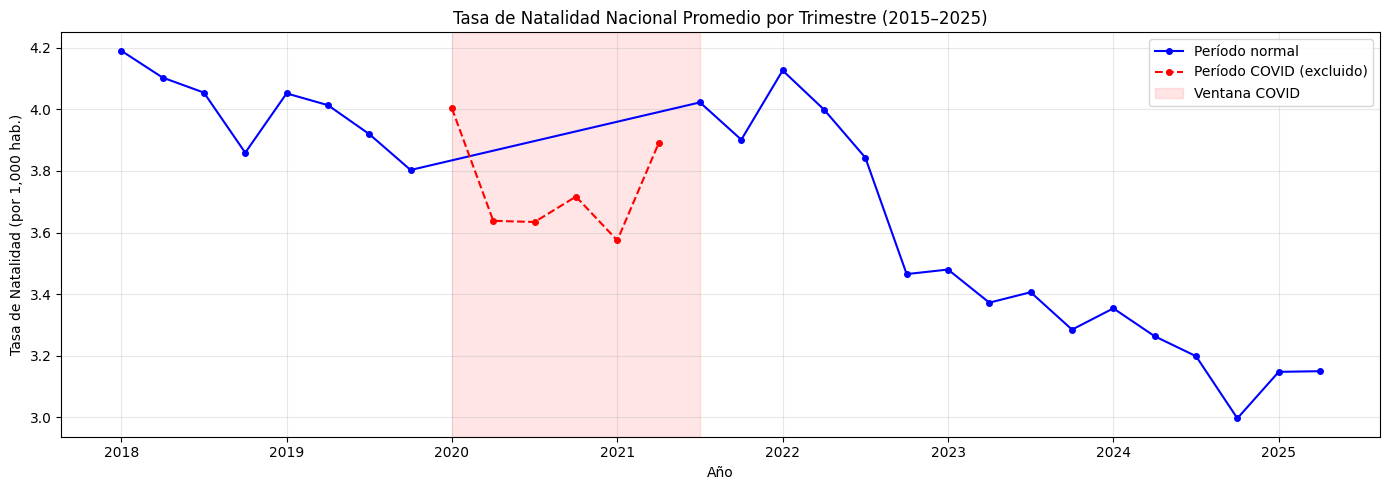

✓ Figura guardada: tasa_natalidad_nacional.png


In [46]:
# ============================================================
# BLOQUE 10: Exclusión COVID y creación de variable período
# ============================================================

# Excluir período COVID: 2020-T1 a 2021-T2
def es_covid(row):
    if row['FecNac_Año'] == 2020:
        return True
    if row['FecNac_Año'] == 2021 and row['Trimestre'] <= 2:
        return True
    return False

# Marcar período COVID
panel_dep['es_covid']  = panel_dep.apply(es_covid, axis=1)
panel_prov['es_covid'] = panel_prov.apply(es_covid, axis=1)

# Crear variable período (año-trimestre como string para visualización)
panel_dep['Periodo']  = (panel_dep['FecNac_Año'].astype(str) +
                          '-T' + panel_dep['Trimestre'].astype(str))
panel_prov['Periodo'] = (panel_prov['FecNac_Año'].astype(str) +
                          '-T' + panel_prov['Trimestre'].astype(str))

# Excluir 2025-T3 y T4 por datos incompletos
panel_dep  = panel_dep[~((panel_dep['FecNac_Año'] == 2025) &
                          (panel_dep['Trimestre'] >= 3))]
panel_prov = panel_prov[~((panel_prov['FecNac_Año'] == 2025) &
                           (panel_prov['Trimestre'] >= 3))]

print("="*60)
print("DISTRIBUCIÓN TEMPORAL")
print("="*60)
print(f"\nPanel departamental sin COVID:")
print(f"  Total:      {panel_dep.shape[0]:,} obs")
print(f"  Sin COVID:  {(~panel_dep['es_covid']).sum():,} obs")
print(f"  Con COVID:  {panel_dep['es_covid'].sum():,} obs")

print(f"\nPanel provincial sin COVID:")
print(f"  Total:      {panel_prov.shape[0]:,} obs")
print(f"  Sin COVID:  {(~panel_prov['es_covid']).sum():,} obs")
print(f"  Con COVID:  {panel_prov['es_covid'].sum():,} obs")

# Dataset de trabajo principal (sin COVID)
panel_dep_clean  = panel_dep[~panel_dep['es_covid']].copy()
panel_prov_clean = panel_prov[~panel_prov['es_covid']].copy()

print(f"\n✓ panel_dep_clean:  {panel_dep_clean.shape[0]:,} obs")
print(f"✓ panel_prov_clean: {panel_prov_clean.shape[0]:,} obs")

# Visualización de la tasa nacional promedio a lo largo del tiempo
tasa_nacional = panel_dep.groupby(['FecNac_Año','Trimestre'])['Tasa_Natalidad'].mean().reset_index()
tasa_nacional['Periodo_num'] = (tasa_nacional['FecNac_Año'] +
                                 (tasa_nacional['Trimestre']-1)/4)

plt.figure(figsize=(14, 5))
covid_mask = tasa_nacional.apply(es_covid, axis=1)
plt.plot(tasa_nacional['Periodo_num'][~covid_mask],
         tasa_nacional['Tasa_Natalidad'][~covid_mask],
         'b-o', markersize=4, label='Período normal')
plt.plot(tasa_nacional['Periodo_num'][covid_mask],
         tasa_nacional['Tasa_Natalidad'][covid_mask],
         'r--o', markersize=4, label='Período COVID (excluido)')
plt.axvspan(2020, 2021.5, alpha=0.1, color='red', label='Ventana COVID')
plt.xlabel('Año')
plt.ylabel('Tasa de Natalidad (por 1,000 hab.)')
plt.title('Tasa de Natalidad Nacional Promedio por Trimestre (2015–2025)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tasa_natalidad_nacional.png', dpi=150)
plt.show()
print("✓ Figura guardada: tasa_natalidad_nacional.png")

In [47]:
# ============================================================
# BLOQUE 11: Ingeniería de Características Temporales
# (Lag1, Lag4, MA4)
# ============================================================

def crear_features_temporales(panel, col_geo):
    """
    Crea lag1, lag4 y ma4 respetando el orden cronológico
    por unidad geográfica, sin filtrar COVID aún
    (se necesitan los valores previos para calcular lags)
    """
    # Ordenar cronológicamente
    panel = panel.sort_values([col_geo, 'FecNac_Año', 'Trimestre']).copy()

    # Crear índice temporal secuencial por unidad geográfica
    panel['t'] = panel.groupby(col_geo).cumcount()

    # Lag1: trimestre anterior
    panel['Lag1'] = panel.groupby(col_geo)['Tasa_Natalidad'].shift(1)

    # Lag4: mismo trimestre del año anterior
    panel['Lag4'] = panel.groupby(col_geo)['Tasa_Natalidad'].shift(4)

    # MA4: media móvil de los 4 trimestres anteriores
    panel['MA4'] = (panel.groupby(col_geo)['Tasa_Natalidad']
                    .transform(lambda x: x.shift(1).rolling(4).mean()))

    return panel

# Aplicar sobre el panel COMPLETO (con COVID) para
# calcular lags correctamente
panel_dep_full  = crear_features_temporales(panel_dep,  'cod_dep')
panel_prov_full = crear_features_temporales(panel_prov, 'cod_prov')

print("✓ Features temporales creadas (panel completo)")
print(f"\nEjemplo — Amazonas (primeros 10 trimestres):")
cols_show = ['Departamento','FecNac_Año','Trimestre',
             'Tasa_Natalidad','Lag1','Lag4','MA4','es_covid']
print(panel_dep_full[panel_dep_full['cod_dep']=='01'][cols_show]
      .head(12).to_string())

# Diagnóstico de nulos en features temporales
print(f"\nNulos en features temporales (panel dep completo):")
print(f"  Lag1: {panel_dep_full['Lag1'].isna().sum()}")
print(f"  Lag4: {panel_dep_full['Lag4'].isna().sum()}")
print(f"  MA4:  {panel_dep_full['MA4'].isna().sum()}")

✓ Features temporales creadas (panel completo)

Ejemplo — Amazonas (primeros 10 trimestres):
   Departamento  FecNac_Año  Trimestre  Tasa_Natalidad      Lag1      Lag4       MA4  es_covid
0      Amazonas        2018          1        3.379915       NaN       NaN       NaN     False
1      Amazonas        2018          2        3.428852  3.379915       NaN       NaN     False
2      Amazonas        2018          3        3.370882  3.428852       NaN       NaN     False
3      Amazonas        2018          4        3.287175  3.370882       NaN       NaN     False
4      Amazonas        2019          1        3.413839  3.287175  3.379915  3.366706     False
5      Amazonas        2019          2        3.370240  3.413839  3.428852  3.375187     False
6      Amazonas        2019          3        3.336198  3.370240  3.370882  3.360534     False
7      Amazonas        2019          4        3.299926  3.336198  3.287175  3.351863     False
8      Amazonas        2020          1        3.3949

In [48]:
# ============================================================
# BLOQUE 12: Construcción de datasets finales de modelado
# ============================================================

def construir_dataset_modelado(panel_full, col_geo, nombre_geo):
    """
    Aplica exclusión COVID, elimina filas con NaN en features
    temporales, y retorna el dataset listo para modelado
    """
    # Excluir período COVID
    df_model = panel_full[~panel_full['es_covid']].copy()

    # Excluir filas donde Lag1, Lag4 o MA4 son NaN
    # (primeros trimestres de cada unidad sin historia suficiente)
    nulos_antes = df_model.shape[0]
    df_model = df_model.dropna(subset=['Lag1', 'Lag4', 'MA4'])
    nulos_despues = df_model.shape[0]

    print(f"\n{'='*50}")
    print(f"DATASET MODELADO — {nombre_geo.upper()}")
    print(f"{'='*50}")
    print(f"  Obs antes de eliminar NaN en lags: {nulos_antes:,}")
    print(f"  Obs eliminadas por NaN en lags:    {nulos_antes - nulos_despues:,}")
    print(f"  Obs finales para modelado:         {nulos_despues:,}")
    print(f"  Unidades geográficas:              {df_model[col_geo].nunique()}")
    print(f"  Rango temporal: {df_model['FecNac_Año'].min()}–"
          f"{df_model['FecNac_Año'].max()}")

    return df_model

df_dep_model  = construir_dataset_modelado(
    panel_dep_full,  'cod_dep',  'Departamental')
df_prov_model = construir_dataset_modelado(
    panel_prov_full, 'cod_prov', 'Provincial')

# Verificar distribución temporal final
print(f"\nDistribución temporal — dataset departamental:")
resumen = (df_dep_model.groupby('FecNac_Año')
           ['Tasa_Natalidad'].agg(['count','mean'])
           .round(4))
resumen.columns = ['N_obs', 'Tasa_Media']
print(resumen.to_string())


DATASET MODELADO — DEPARTAMENTAL
  Obs antes de eliminar NaN en lags: 600
  Obs eliminadas por NaN en lags:    100
  Obs finales para modelado:         500
  Unidades geográficas:              25
  Rango temporal: 2019–2025

DATASET MODELADO — PROVINCIAL
  Obs antes de eliminar NaN en lags: 4,704
  Obs eliminadas por NaN en lags:    784
  Obs finales para modelado:         3,920
  Unidades geográficas:              196
  Rango temporal: 2019–2025

Distribución temporal — dataset departamental:
            N_obs  Tasa_Media
FecNac_Año                   
2019          100      3.9470
2021           50      3.9620
2022          100      3.8585
2023          100      3.3860
2024          100      3.2033
2025           50      3.1490


In [50]:
# ============================================================
# BLOQUE 13: Definición de variables X e Y, y splits
#            temporales (Train / Val / Test)
# ============================================================

# ── Features por categoría ───────────────────────────────────
FEATURES_TEMP = ['FecNac_Año', 'Trimestre', 'Lag1', 'Lag4', 'MA4']

FEATURES_SOCIO = [
    'Edad_Media', 'Pct_Adolescentes', 'Pct_Mayor35',
    'Prom_Embarazos', 'Prom_HijosVivos', 'Prom_Abortos',
    'Pct_Casado', 'Pct_Conviviente', 'Pct_Soltero',
    'Pct_Educ_Superior', 'Pct_Educ_Secundaria',
    'Pct_Educ_Primaria', 'Pct_Educ_SinInstruccion',
    'Pct_SIS', 'Pct_EsSalud', 'Pct_Particular',
    'Pct_Establecimiento', 'Pct_Domicilio'
]

TARGET = 'Tasa_Natalidad'

def split_temporal(df, año_val_inicio=2023, año_test_inicio=2024):
    """
    Train:      hasta 2022 (inclusive)
    Validación: 2023
    Test:       2024–2025
    """
    train = df[df['FecNac_Año'] < año_val_inicio].copy()
    val   = df[df['FecNac_Año'] == año_val_inicio].copy()
    test  = df[df['FecNac_Año'] >= año_test_inicio].copy()
    return train, val, test

# Splits departamentales
train_dep, val_dep, test_dep = split_temporal(df_dep_model)

# Splits provinciales
train_prov, val_prov, test_prov = split_temporal(df_prov_model)

print("="*55)
print("SPLITS TEMPORALES — DEPARTAMENTAL")
print("="*55)
print(f"  Train (2018–2022): {train_dep.shape[0]:,} obs")
print(f"  Val   (2023):      {val_dep.shape[0]:,} obs")
print(f"  Test  (2024–2025): {test_dep.shape[0]:,} obs")

print(f"\n{'='*55}")
print("SPLITS TEMPORALES — PROVINCIAL")
print("="*55)
print(f"  Train (2018–2022): {train_prov.shape[0]:,} obs")
print(f"  Val   (2023):      {val_prov.shape[0]:,} obs")
print(f"  Test  (2024–2025): {test_prov.shape[0]:,} obs")

# Verificar que no hay data leakage
print(f"\n✓ Verificación de no-leakage:")
print(f"  Año máx en train_dep: {train_dep['FecNac_Año'].max()}")
print(f"  Año mín en test_dep:  {test_dep['FecNac_Año'].min()}")
print(f"  Año máx en train_prov: {train_prov['FecNac_Año'].max()}")
print(f"  Año mín en test_prov:  {test_prov['FecNac_Año'].min()}")

SPLITS TEMPORALES — DEPARTAMENTAL
  Train (2018–2022): 250 obs
  Val   (2023):      100 obs
  Test  (2024–2025): 150 obs

SPLITS TEMPORALES — PROVINCIAL
  Train (2018–2022): 1,960 obs
  Val   (2023):      784 obs
  Test  (2024–2025): 1,176 obs

✓ Verificación de no-leakage:
  Año máx en train_dep: 2022
  Año mín en test_dep:  2024
  Año máx en train_prov: 2022
  Año mín en test_prov:  2024


In [51]:
# ============================================================
# BLOQUE 14: Pipeline de preprocesamiento y entrenamiento
#            E1 — Comparación base de 5 modelos (departamental)
# ============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# ── Configuración de features para E1 (completa) ────────────
FEATURES_GEO_DEP  = ['cod_dep']   # one-hot encoding
FEATURES_ALL_DEP  = FEATURES_TEMP + FEATURES_SOCIO  # sin geo (se añade aparte)

# Features numéricas (escalar) y categóricas (one-hot)
num_features  = FEATURES_TEMP + FEATURES_SOCIO
cat_features  = ['cod_dep']

preprocessor_dep = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     cat_features)
], remainder='drop')

# ── Modelos a evaluar ────────────────────────────────────────
modelos = {
    'Regresión Lineal': LinearRegression(),
    'KNN (k=5)':        KNeighborsRegressor(n_neighbors=5),
    'KNN (k=10)':       KNeighborsRegressor(n_neighbors=10),
    'Árbol Regresión':  DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':    RandomForestRegressor(n_estimators=100, max_depth=6,
                                              random_state=42, n_jobs=-1),
    'XGBoost':          XGBRegressor(n_estimators=200, learning_rate=0.05,
                                     max_depth=6, random_state=42,
                                     verbosity=0)
}

# ── Dataset E1: train+val departamental, features completas ──
X_dep_tv = pd.concat([train_dep, val_dep])[num_features + cat_features]
y_dep_tv = pd.concat([train_dep, val_dep])[TARGET]

# TimeSeriesSplit sobre train+val
tscv = TimeSeriesSplit(n_splits=5)

print("="*60)
print("E1 — VALIDACIÓN CRUZADA TEMPORAL (DEPARTAMENTAL)")
print("="*60)

resultados_cv = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ('prep', preprocessor_dep),
        ('model', modelo)
    ])

    # R²
    r2_scores = cross_val_score(pipe, X_dep_tv, y_dep_tv,
                                 cv=tscv, scoring='r2')
    # RMSE
    rmse_scores = cross_val_score(pipe, X_dep_tv, y_dep_tv,
                                   cv=tscv,
                                   scoring='neg_root_mean_squared_error')
    # MAE
    mae_scores = cross_val_score(pipe, X_dep_tv, y_dep_tv,
                                  cv=tscv,
                                  scoring='neg_mean_absolute_error')

    resultados_cv[nombre] = {
        'R2_mean':   r2_scores.mean(),
        'R2_std':    r2_scores.std(),
        'RMSE_mean': (-rmse_scores).mean(),
        'MAE_mean':  (-mae_scores).mean()
    }

    print(f"\n{nombre}:")
    print(f"  R²   = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"  RMSE = {(-rmse_scores).mean():.4f}")
    print(f"  MAE  = {(-mae_scores).mean():.4f}")

# Tabla resumen
df_cv = pd.DataFrame(resultados_cv).T.round(4)
df_cv = df_cv.sort_values('R2_mean', ascending=False)
print(f"\n{'='*60}")
print("TABLA RESUMEN — VALIDACIÓN CRUZADA")
print("="*60)
print(df_cv.to_string())

E1 — VALIDACIÓN CRUZADA TEMPORAL (DEPARTAMENTAL)

Regresión Lineal:
  R²   = 0.7457 ± 0.1946
  RMSE = 0.3919
  MAE  = 0.2772

KNN (k=5):
  R²   = 0.5670 ± 0.0827
  RMSE = 0.5544
  MAE  = 0.4545

KNN (k=10):
  R²   = 0.5980 ± 0.0880
  RMSE = 0.5322
  MAE  = 0.4404

Árbol Regresión:
  R²   = 0.6969 ± 0.0990
  RMSE = 0.4593
  MAE  = 0.3482

Random Forest:
  R²   = 0.7833 ± 0.1289
  RMSE = 0.3778
  MAE  = 0.2704

XGBoost:
  R²   = 0.7704 ± 0.1485
  RMSE = 0.3885
  MAE  = 0.2834

TABLA RESUMEN — VALIDACIÓN CRUZADA
                  R2_mean  R2_std  RMSE_mean  MAE_mean
Random Forest      0.7833  0.1289     0.3778    0.2704
XGBoost            0.7704  0.1485     0.3885    0.2834
Regresión Lineal   0.7457  0.1946     0.3919    0.2772
Árbol Regresión    0.6969  0.0990     0.4593    0.3482
KNN (k=10)         0.5980  0.0880     0.5322    0.4404
KNN (k=5)          0.5670  0.0827     0.5544    0.4545


E1 — EVALUACIÓN EN TEST (XGBoost, Departamental)
  R²   en test: 0.9044
  RMSE en test: 0.2197
  MAE  en test: 0.1645


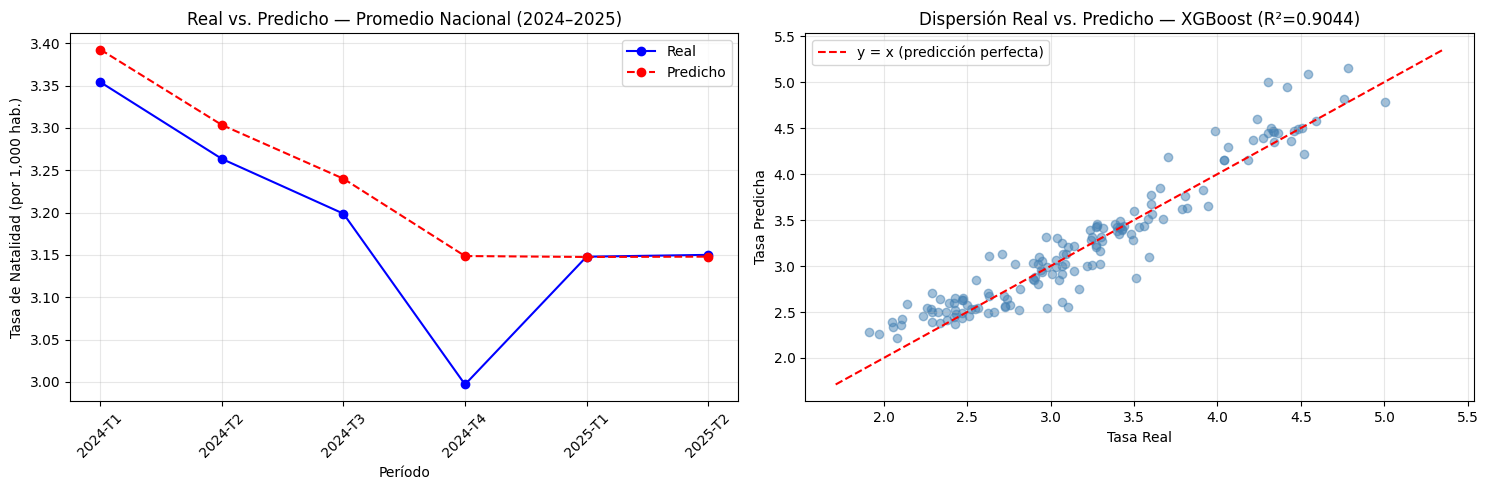

✓ Figura guardada: e1_xgboost_test_departamental.png


In [53]:
# ============================================================
# BLOQUE 15: Entrenamiento final XGBoost y evaluación en test
#            (E1 continuación)
# ============================================================

# Entrenar XGBoost con train+val completo
X_train_full = pd.concat([train_dep, val_dep])[num_features + cat_features]
y_train_full = pd.concat([train_dep, val_dep])[TARGET]

X_test_dep = test_dep[num_features + cat_features]
y_test_dep = test_dep[TARGET]

pipe_xgb_dep = Pipeline([
    ('prep', preprocessor_dep),
    ('model', XGBRegressor(n_estimators=200, learning_rate=0.05,
                           max_depth=6, random_state=42, verbosity=0))
])

pipe_xgb_dep.fit(X_train_full, y_train_full)
y_pred_dep = pipe_xgb_dep.predict(X_test_dep)

r2_test  = r2_score(y_test_dep, y_pred_dep)
rmse_test = np.sqrt(mean_squared_error(y_test_dep, y_pred_dep))
mae_test  = mean_absolute_error(y_test_dep, y_pred_dep)

print("="*55)
print("E1 — EVALUACIÓN EN TEST (XGBoost, Departamental)")
print("="*55)
print(f"  R²   en test: {r2_test:.4f}")
print(f"  RMSE en test: {rmse_test:.4f}")
print(f"  MAE  en test: {mae_test:.4f}")

# ── Figura 1: Real vs Predicho (líneas por trimestre) ────────
test_dep_plot = test_dep.copy()
test_dep_plot['Predicho'] = y_pred_dep
test_dep_plot['Periodo_num'] = (test_dep_plot['FecNac_Año'] +
                                 (test_dep_plot['Trimestre']-1)/4)

# Promedio nacional por período
real_prom    = test_dep_plot.groupby('Periodo_num')['Tasa_Natalidad'].mean()
pred_prom    = test_dep_plot.groupby('Periodo_num')['Predicho'].mean()
periodos_str = test_dep_plot.groupby('Periodo_num')['Periodo'].first()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de líneas
axes[0].plot(real_prom.values, 'b-o', label='Real', markersize=6)
axes[0].plot(pred_prom.values, 'r--o', label='Predicho', markersize=6)
axes[0].set_xticks(range(len(periodos_str)))
axes[0].set_xticklabels(periodos_str.values, rotation=45)
axes[0].set_xlabel('Período')
axes[0].set_ylabel('Tasa de Natalidad (por 1,000 hab.)')
axes[0].set_title('Real vs. Predicho — Promedio Nacional (2024–2025)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de dispersión
axes[1].scatter(y_test_dep, y_pred_dep, alpha=0.5, color='steelblue')
lims = [min(y_test_dep.min(), y_pred_dep.min()) - 0.2,
        max(y_test_dep.max(), y_pred_dep.max()) + 0.2]
axes[1].plot(lims, lims, 'r--', label='y = x (predicción perfecta)')
axes[1].set_xlabel('Tasa Real')
axes[1].set_ylabel('Tasa Predicha')
axes[1].set_title(f'Dispersión Real vs. Predicho — XGBoost (R²={r2_test:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('e1_xgboost_test_departamental.png', dpi=150)
plt.show()
print("✓ Figura guardada: e1_xgboost_test_departamental.png")

IMPORTANCIA DE VARIABLES POR CATEGORÍA
         Categoria  Importancia       Pct
          Temporal     0.843581 84.360001
  Sociodemográfico     0.060373  6.040000
        Geográfico     0.039393  3.940000
      Edad Materna     0.038743  3.870000
Salud Reproductiva     0.017910  1.790000


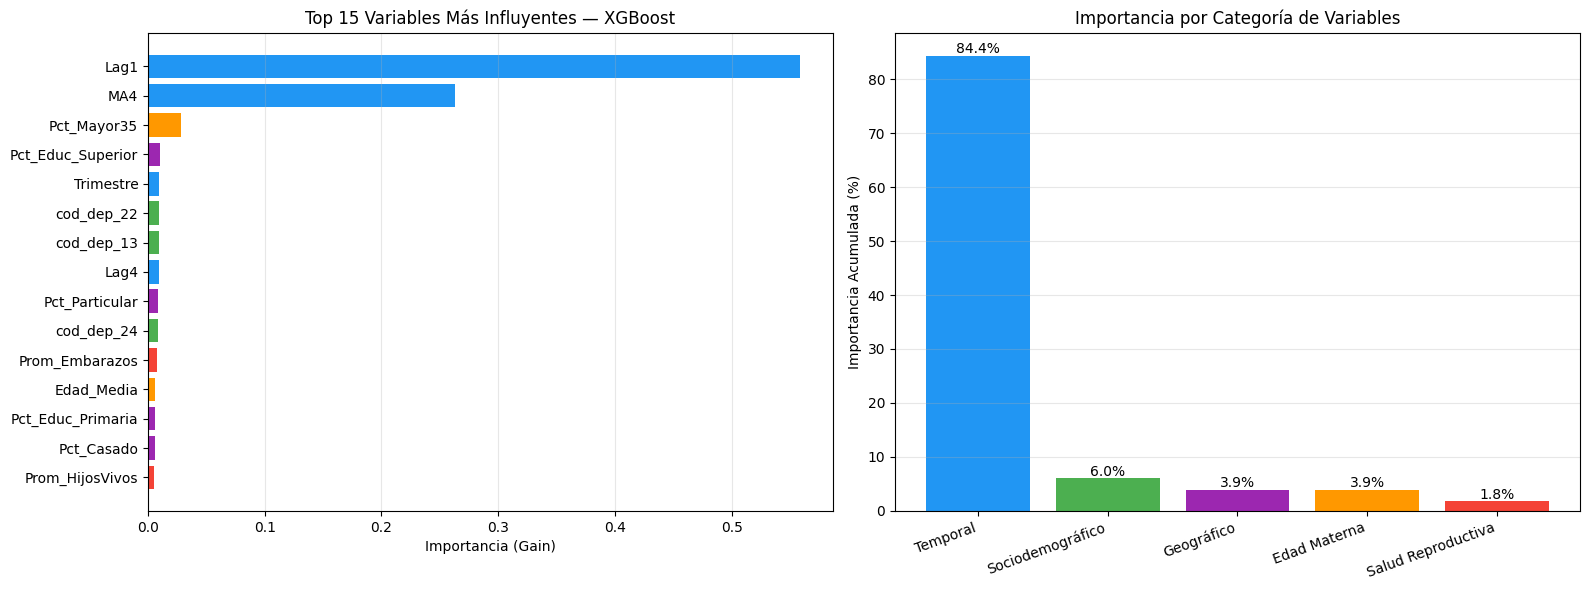

✓ Figura guardada: e1_importancia_variables.png


In [54]:
# ============================================================
# BLOQUE 16: Importancia de variables — XGBoost departamental
# ============================================================

# Extraer importancias del modelo XGBoost dentro del pipeline
xgb_model = pipe_xgb_dep.named_steps['model']
prep_model = pipe_xgb_dep.named_steps['prep']

# Nombres de features tras preprocesamiento
num_names = num_features
cat_names = list(prep_model.named_transformers_['cat']
                 .get_feature_names_out(['cod_dep']))
all_feature_names = num_names + cat_names

importancias = pd.DataFrame({
    'Feature':     all_feature_names,
    'Importancia': xgb_model.feature_importances_
}).sort_values('Importancia', ascending=False)

# Top 15
top15 = importancias.head(15)

# ── Agrupación por categoría ─────────────────────────────────
def categorizar_feature(f):
    if f in ['Lag1','Lag4','MA4','FecNac_Año','Trimestre']:
        return 'Temporal'
    elif f.startswith('cod_dep'):
        return 'Geográfico'
    elif f in ['Edad_Media','Pct_Adolescentes','Pct_Mayor35']:
        return 'Edad Materna'
    elif f in ['Pct_Educ_Superior','Pct_Educ_Secundaria',
               'Pct_Educ_Primaria','Pct_Educ_SinInstruccion',
               'Pct_Casado','Pct_Conviviente','Pct_Soltero',
               'Pct_Establecimiento','Pct_Domicilio',
               'Pct_SIS','Pct_EsSalud','Pct_Particular']:
        return 'Sociodemográfico'
    elif f in ['Prom_Embarazos','Prom_HijosVivos','Prom_Abortos']:
        return 'Salud Reproductiva'
    return 'Otro'

importancias['Categoria'] = importancias['Feature'].apply(categorizar_feature)

imp_categoria = (importancias.groupby('Categoria')['Importancia']
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())
imp_categoria['Pct'] = (imp_categoria['Importancia'] /
                         imp_categoria['Importancia'].sum() * 100).round(2)

print("="*55)
print("IMPORTANCIA DE VARIABLES POR CATEGORÍA")
print("="*55)
print(imp_categoria.to_string(index=False))

# ── Figura: Top 15 + Por categoría ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 features
colors = top15['Feature'].apply(
    lambda f: {'Temporal':'#2196F3','Geográfico':'#4CAF50',
               'Edad Materna':'#FF9800','Sociodemográfico':'#9C27B0',
               'Salud Reproductiva':'#F44336'}.get(categorizar_feature(f),'gray')
)
axes[0].barh(top15['Feature'][::-1], top15['Importancia'][::-1],
             color=colors[::-1])
axes[0].set_xlabel('Importancia (Gain)')
axes[0].set_title('Top 15 Variables Más Influyentes — XGBoost')
axes[0].grid(True, alpha=0.3, axis='x')

# Por categoría
colores_cat = ['#2196F3','#4CAF50','#9C27B0','#FF9800','#F44336']
axes[1].bar(imp_categoria['Categoria'], imp_categoria['Pct'],
            color=colores_cat[:len(imp_categoria)])
axes[1].set_ylabel('Importancia Acumulada (%)')
axes[1].set_title('Importancia por Categoría de Variables')
axes[1].set_xticklabels(imp_categoria['Categoria'], rotation=20, ha='right')
for i, (_, row) in enumerate(imp_categoria.iterrows()):
    axes[1].text(i, row['Pct'] + 0.5, f"{row['Pct']:.1f}%",
                 ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('e1_importancia_variables.png', dpi=150)
plt.show()
print("✓ Figura guardada: e1_importancia_variables.png")

In [56]:
# ============================================================
# BLOQUE 17: E2 — Estudio de Ablación por categoría
#            (Solo Temporal vs Solo Socio vs Completa)
# ============================================================

# ── Configuraciones de ablación ──────────────────────────────
configuraciones = {
    '(a) Solo Temporal':        FEATURES_TEMP,
    '(b) Solo Sociodemográfico': FEATURES_SOCIO,
    '(c) Completa':             FEATURES_TEMP + FEATURES_SOCIO
}

# Nota: la config completa incluye cod_dep via one-hot en (c)
# En (a) y (b) NO incluimos cod_dep para aislar la señal pura

def crear_pipeline_ablacion(features_num, incluir_geo=False):
    """
    Crea pipeline con o sin variables geográficas (one-hot dep)
    """
    if incluir_geo:
        preprocessor = ColumnTransformer(transformers=[
            ('num', StandardScaler(), features_num),
            ('cat', OneHotEncoder(handle_unknown='ignore',
                                   sparse_output=False), ['cod_dep'])
        ], remainder='drop')
        feature_cols = features_num + ['cod_dep']
    else:
        preprocessor = ColumnTransformer(transformers=[
            ('num', StandardScaler(), features_num),
        ], remainder='drop')
        feature_cols = features_num

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', XGBRegressor(n_estimators=200, learning_rate=0.05,
                               max_depth=6, random_state=42, verbosity=0))
    ])
    return pipe, feature_cols

print("="*60)
print("E2 — ESTUDIO DE ABLACIÓN (XGBoost, Departamental)")
print("="*60)

resultados_ablacion = {}
r2_por_fold = {}

for nombre_config, features in configuraciones.items():
    incluir_geo = (nombre_config == '(c) Completa')
    pipe, cols = crear_pipeline_ablacion(features, incluir_geo)

    # Dataset para esta configuración
    X_ablacion = pd.concat([train_dep, val_dep])[cols]
    y_ablacion = pd.concat([train_dep, val_dep])[TARGET]

    # Validación cruzada temporal
    r2_scores   = cross_val_score(pipe, X_ablacion, y_ablacion,
                                   cv=tscv, scoring='r2')
    rmse_scores = cross_val_score(pipe, X_ablacion, y_ablacion,
                                   cv=tscv,
                                   scoring='neg_root_mean_squared_error')
    mae_scores  = cross_val_score(pipe, X_ablacion, y_ablacion,
                                   cv=tscv,
                                   scoring='neg_mean_absolute_error')

    resultados_ablacion[nombre_config] = {
        'R2_mean':   r2_scores.mean(),
        'R2_std':    r2_scores.std(),
        'RMSE_mean': (-rmse_scores).mean(),
        'MAE_mean':  (-mae_scores).mean()
    }
    r2_por_fold[nombre_config] = r2_scores

    print(f"\n{nombre_config}:")
    print(f"  Features: {len(features)} variables")
    print(f"  R²   = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"  RMSE = {(-rmse_scores).mean():.4f}")
    print(f"  MAE  = {(-mae_scores).mean():.4f}")
    print(f"  R² por fold: {np.round(r2_scores, 4)}")

# Tabla resumen ablación
df_ablacion = pd.DataFrame(resultados_ablacion).T.round(4)
print(f"\n{'='*60}")
print("TABLA RESUMEN — ABLACIÓN")
print("="*60)
print(df_ablacion.to_string())

# Contribución marginal de variables sociodemográficas
delta_r2 = (resultados_ablacion['(c) Completa']['R2_mean'] -
            resultados_ablacion['(a) Solo Temporal']['R2_mean'])
print(f"\n▶ Contribución marginal de X_socio + X_geo")
print(f"  sobre X_temp: ΔR² = {delta_r2:.4f}")

E2 — ESTUDIO DE ABLACIÓN (XGBoost, Departamental)

(a) Solo Temporal:
  Features: 5 variables
  R²   = 0.7974 ± 0.1516
  RMSE = 0.3592
  MAE  = 0.2552
  R² por fold: [0.5    0.9034 0.8911 0.8168 0.8757]

(b) Solo Sociodemográfico:
  Features: 18 variables
  R²   = 0.2016 ± 0.3403
  RMSE = 0.7304
  MAE  = 0.5904
  R² por fold: [ 0.1964  0.0413 -0.3434  0.5126  0.601 ]

(c) Completa:
  Features: 23 variables
  R²   = 0.7704 ± 0.1485
  RMSE = 0.3885
  MAE  = 0.2834
  R² por fold: [0.4783 0.8545 0.8687 0.7915 0.8588]

TABLA RESUMEN — ABLACIÓN
                           R2_mean  R2_std  RMSE_mean  MAE_mean
(a) Solo Temporal           0.7974  0.1516     0.3592    0.2552
(b) Solo Sociodemográfico   0.2016  0.3403     0.7304    0.5904
(c) Completa                0.7704  0.1485     0.3885    0.2834

▶ Contribución marginal de X_socio + X_geo
  sobre X_temp: ΔR² = -0.0270


E2 — EVALUACIÓN EN TEST POR CONFIGURACIÓN

(a) Solo Temporal:
  R²   en test = 0.9095
  RMSE en test = 0.2138
  MAE  en test = 0.1594

(b) Solo Sociodemográfico:
  R²   en test = 0.5305
  RMSE en test = 0.4869
  MAE  en test = 0.4054

(c) Completa:
  R²   en test = 0.9044
  RMSE en test = 0.2197
  MAE  en test = 0.1645

TABLA RESUMEN — TEST POR CONFIGURACIÓN
                           R2_test  RMSE_test  MAE_test
(a) Solo Temporal           0.9095     0.2138    0.1594
(b) Solo Sociodemográfico   0.5305     0.4869    0.4054
(c) Completa                0.9044     0.2197    0.1645


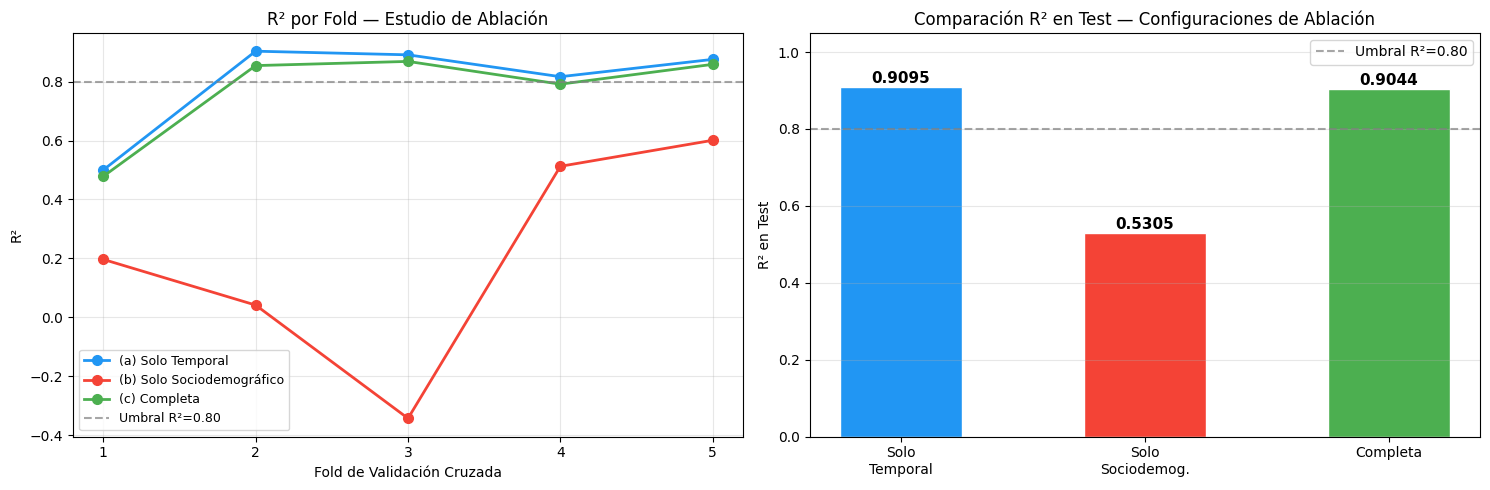

✓ Figura guardada: e2_ablacion_comparativa.png


In [57]:
# ============================================================
# BLOQUE 18: Evaluación en TEST de cada configuración de
#            ablación + figura comparativa
# ============================================================

print("="*60)
print("E2 — EVALUACIÓN EN TEST POR CONFIGURACIÓN")
print("="*60)

test_scores_ablacion = {}
for nombre_config, features in configuraciones.items():
    incluir_geo = (nombre_config == '(c) Completa')
    pipe, cols = crear_pipeline_ablacion(features, incluir_geo)

    # Entrenar con train+val
    X_tv = pd.concat([train_dep, val_dep])[cols]
    y_tv = pd.concat([train_dep, val_dep])[TARGET]
    X_te = test_dep[cols]
    y_te = test_dep[TARGET]

    pipe.fit(X_tv, y_tv)
    y_pred = pipe.predict(X_te)

    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)

    test_scores_ablacion[nombre_config] = {
        'R2_test': r2, 'RMSE_test': rmse, 'MAE_test': mae
    }
    print(f"\n{nombre_config}:")
    print(f"  R²   en test = {r2:.4f}")
    print(f"  RMSE en test = {rmse:.4f}")
    print(f"  MAE  en test = {mae:.4f}")

df_test_ablacion = pd.DataFrame(test_scores_ablacion).T.round(4)
print(f"\n{'='*60}")
print("TABLA RESUMEN — TEST POR CONFIGURACIÓN")
print("="*60)
print(df_test_ablacion.to_string())

# ── Figura: R² por fold y barras de test ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² por fold (líneas)
colores_abl = {'(a) Solo Temporal': '#2196F3',
               '(b) Solo Sociodemográfico': '#F44336',
               '(c) Completa': '#4CAF50'}
folds = range(1, 6)
for nombre_config, r2_folds in r2_por_fold.items():
    axes[0].plot(folds, r2_folds, 'o-',
                 label=nombre_config,
                 color=colores_abl[nombre_config],
                 linewidth=2, markersize=7)
axes[0].axhline(0.80, color='gray', linestyle='--',
                alpha=0.7, label='Umbral R²=0.80')
axes[0].set_xlabel('Fold de Validación Cruzada')
axes[0].set_ylabel('R²')
axes[0].set_title('R² por Fold — Estudio de Ablación')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(folds)

# Barras comparativas en test
configs     = list(test_scores_ablacion.keys())
r2_vals     = [test_scores_ablacion[c]['R2_test'] for c in configs]
colores_bar = [colores_abl[c] for c in configs]

bars = axes[1].bar(configs, r2_vals, color=colores_bar,
                    width=0.5, edgecolor='white')
axes[1].axhline(0.80, color='gray', linestyle='--',
                alpha=0.7, label='Umbral R²=0.80')
axes[1].set_ylabel('R² en Test')
axes[1].set_title('Comparación R² en Test — Configuraciones de Ablación')
axes[1].set_xticklabels(
    ['Solo\nTemporal', 'Solo\nSociodemog.', 'Completa'],
    fontsize=10)
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.01, f'{val:.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('e2_ablacion_comparativa.png', dpi=150)
plt.show()
print("✓ Figura guardada: e2_ablacion_comparativa.png")

E3 — VALIDACIÓN CRUZADA TEMPORAL (PROVINCIAL)
  R²   = 0.7050 ± 0.0893
  RMSE = 0.6364
  MAE  = 0.4239
  R² por fold: [0.5822 0.6885 0.7994 0.6421 0.8131]

E3 — EVALUACIÓN EN TEST (PROVINCIAL)
  R²   en test = 0.8210
  RMSE en test = 0.4498
  MAE  en test = 0.3265

COMPARACIÓN DEPARTAMENTAL vs. PROVINCIAL
             Nivel  R² CV  RMSE CV  MAE CV  R² Test  RMSE Test  MAE Test
Departamental (25) 0.7704   0.3885  0.2834   0.9044     0.2197    0.1645
  Provincial (196) 0.7050   0.6364  0.4239   0.8210     0.4498    0.3265

Top 15 provincias con mayor error (MAE):
           Provincia  MAE_prov  N_obs
           Candarave  1.242666      6
           Yarowilca  1.220936      6
              Maynas  1.128185      6
                Aija  0.946906      6
           Cajatambo  0.851515      6
               Purus  0.804966      6
              Tarata  0.793179      6
           Tahuamanu  0.774581      6
               Ocros  0.736054      6
       Huanca Sancos  0.703753      6
General Sanche

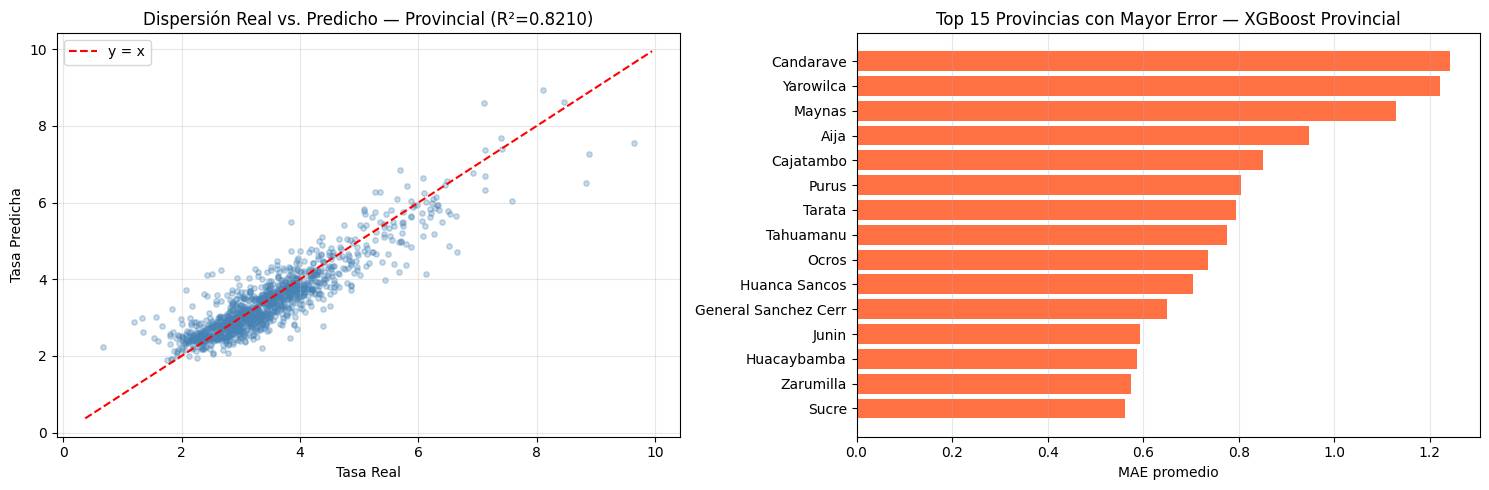

✓ Figura guardada: e3_provincial.png


In [58]:
# ============================================================
# BLOQUE 19: E3 — Extensión Provincial
# ============================================================

# Preprocessor para nivel provincial
num_features_prov = FEATURES_TEMP + FEATURES_SOCIO
cat_features_prov = ['cod_prov']

preprocessor_prov = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features_prov),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     cat_features_prov)
], remainder='drop')

pipe_xgb_prov = Pipeline([
    ('prep', preprocessor_prov),
    ('model', XGBRegressor(n_estimators=200, learning_rate=0.05,
                           max_depth=6, random_state=42, verbosity=0))
])

# Features provinciales
cols_prov = num_features_prov + cat_features_prov

X_prov_tv = pd.concat([train_prov, val_prov])[cols_prov]
y_prov_tv = pd.concat([train_prov, val_prov])[TARGET]
X_prov_te = test_prov[cols_prov]
y_prov_te = test_prov[TARGET]

# Validación cruzada temporal provincial
tscv_prov = TimeSeriesSplit(n_splits=5)

r2_prov_cv   = cross_val_score(pipe_xgb_prov, X_prov_tv, y_prov_tv,
                                cv=tscv_prov, scoring='r2')
rmse_prov_cv = cross_val_score(pipe_xgb_prov, X_prov_tv, y_prov_tv,
                                cv=tscv_prov,
                                scoring='neg_root_mean_squared_error')
mae_prov_cv  = cross_val_score(pipe_xgb_prov, X_prov_tv, y_prov_tv,
                                cv=tscv_prov,
                                scoring='neg_mean_absolute_error')

print("="*60)
print("E3 — VALIDACIÓN CRUZADA TEMPORAL (PROVINCIAL)")
print("="*60)
print(f"  R²   = {r2_prov_cv.mean():.4f} ± {r2_prov_cv.std():.4f}")
print(f"  RMSE = {(-rmse_prov_cv).mean():.4f}")
print(f"  MAE  = {(-mae_prov_cv).mean():.4f}")
print(f"  R² por fold: {np.round(r2_prov_cv, 4)}")

# Entrenamiento final y evaluación en test provincial
pipe_xgb_prov.fit(X_prov_tv, y_prov_tv)
y_pred_prov = pipe_xgb_prov.predict(X_prov_te)

r2_prov_test   = r2_score(y_prov_te, y_pred_prov)
rmse_prov_test = np.sqrt(mean_squared_error(y_prov_te, y_pred_prov))
mae_prov_test  = mean_absolute_error(y_prov_te, y_pred_prov)

print(f"\nE3 — EVALUACIÓN EN TEST (PROVINCIAL)")
print(f"  R²   en test = {r2_prov_test:.4f}")
print(f"  RMSE en test = {rmse_prov_test:.4f}")
print(f"  MAE  en test = {mae_prov_test:.4f}")

# ── Tabla comparativa Dep vs Prov ────────────────────────────
print(f"\n{'='*60}")
print("COMPARACIÓN DEPARTAMENTAL vs. PROVINCIAL")
print("="*60)
comp = pd.DataFrame({
    'Nivel':     ['Departamental (25)', 'Provincial (196)'],
    'R² CV':     [resultados_cv['XGBoost']['R2_mean'], r2_prov_cv.mean()],
    'RMSE CV':   [resultados_cv['XGBoost']['RMSE_mean'], (-rmse_prov_cv).mean()],
    'MAE CV':    [resultados_cv['XGBoost']['MAE_mean'],  (-mae_prov_cv).mean()],
    'R² Test':   [r2_test, r2_prov_test],
    'RMSE Test': [rmse_test, rmse_prov_test],
    'MAE Test':  [mae_test, mae_prov_test],
}).round(4)
print(comp.to_string(index=False))

# ── Error MAE por provincia (top 15 con mayor error) ─────────
test_prov_plot = test_prov.copy()
test_prov_plot['Predicho'] = y_pred_prov
test_prov_plot['Error_Abs'] = np.abs(
    test_prov_plot['Tasa_Natalidad'] - test_prov_plot['Predicho'])

error_por_prov = (test_prov_plot.groupby('cod_prov')
                  .agg(Provincia=('Provincia','first'),
                       MAE_prov=('Error_Abs','mean'),
                       N_obs=('Error_Abs','count'))
                  .reset_index()
                  .sort_values('MAE_prov', ascending=False))

print(f"\nTop 15 provincias con mayor error (MAE):")
print(error_por_prov.head(15)[
    ['Provincia','MAE_prov','N_obs']].to_string(index=False))

# Figura dispersión provincial
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_prov_te, y_pred_prov, alpha=0.3,
                color='steelblue', s=15)
lims = [min(y_prov_te.min(), y_pred_prov.min()) - 0.3,
        max(y_prov_te.max(), y_pred_prov.max()) + 0.3]
axes[0].plot(lims, lims, 'r--', label='y = x')
axes[0].set_xlabel('Tasa Real')
axes[0].set_ylabel('Tasa Predicha')
axes[0].set_title(f'Dispersión Real vs. Predicho — Provincial '
                   f'(R²={r2_prov_test:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top15_err = error_por_prov.head(15)
axes[1].barh(top15_err['Provincia'][::-1],
             top15_err['MAE_prov'][::-1],
             color='#FF7043')
axes[1].set_xlabel('MAE promedio')
axes[1].set_title('Top 15 Provincias con Mayor Error — XGBoost Provincial')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('e3_provincial.png', dpi=150)
plt.show()
print("✓ Figura guardada: e3_provincial.png")

E4 — ROBUSTEZ COVID-19 (XGBoost, Departamental)

Con COVID en entrenamiento:
  R²   en test = 0.8784
  RMSE en test = 0.2478
  MAE  en test = 0.1912

Sin COVID en entrenamiento:
  R²   en test = 0.9044
  RMSE en test = 0.2197
  MAE  en test = 0.1645

TABLA COMPARATIVA — IMPACTO COVID
               Condición  R² Test  RMSE Test  MAE Test
Sin COVID (2020–2021-T2)   0.9044     0.2197    0.1645
Con COVID (2020–2021-T2)   0.8784     0.2478    0.1912

▶ Mejora por exclusión COVID: ΔR² = +0.0260


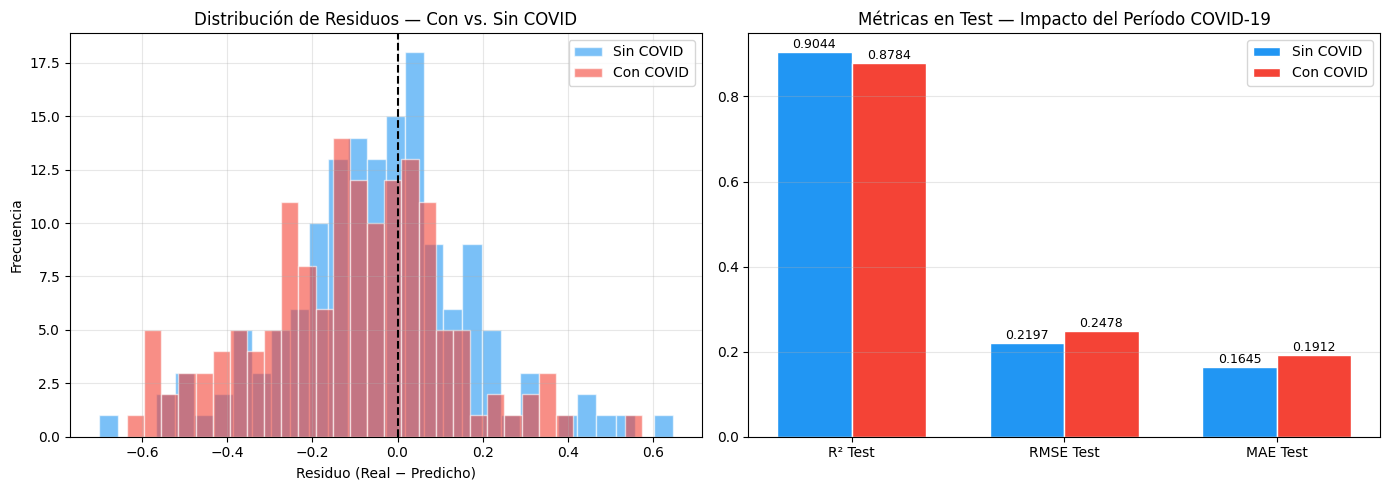

✓ Figura guardada: e4_covid_robustez.png


In [60]:
# ============================================================
# BLOQUE 20: E4 — Robustez ante período COVID-19
# ============================================================

print("="*60)
print("E4 — ROBUSTEZ COVID-19 (XGBoost, Departamental)")
print("="*60)

cols_completas = num_features + cat_features

# ── Escenario SIN COVID (ya definido) ────────────────────────
# pipe_xgb_dep ya fue entrenado sin COVID → r2_test=0.9288

# ── Escenario CON COVID ──────────────────────────────────────
# Reconstruir splits incluyendo período COVID
panel_dep_con_covid = panel_dep_full.copy()  # panel completo con COVID

# Aplicar features temporales ya calculadas
# Split temporal incluyendo COVID en entrenamiento
train_covid = panel_dep_con_covid[
    panel_dep_con_covid['FecNac_Año'] < 2023
].dropna(subset=['Lag1','Lag4','MA4']).copy()

val_covid   = panel_dep_con_covid[
    panel_dep_con_covid['FecNac_Año'] == 2023
].dropna(subset=['Lag1','Lag4','MA4']).copy()

test_covid  = panel_dep_con_covid[
    panel_dep_con_covid['FecNac_Año'] >= 2024
].dropna(subset=['Lag1','Lag4','MA4']).copy()

X_tv_covid = pd.concat([train_covid, val_covid])[cols_completas]
y_tv_covid = pd.concat([train_covid, val_covid])[TARGET]
X_te_covid = test_covid[cols_completas]
y_te_covid = test_covid[TARGET]

# Entrenar con COVID incluido
pipe_xgb_covid = Pipeline([
    ('prep', preprocessor_dep),
    ('model', XGBRegressor(n_estimators=200, learning_rate=0.05,
                           max_depth=6, random_state=42, verbosity=0))
])
pipe_xgb_covid.fit(X_tv_covid, y_tv_covid)
y_pred_covid = pipe_xgb_covid.predict(X_te_covid)

r2_covid   = r2_score(y_te_covid, y_pred_covid)
rmse_covid = np.sqrt(mean_squared_error(y_te_covid, y_pred_covid))
mae_covid  = mean_absolute_error(y_te_covid, y_pred_covid)

print(f"\nCon COVID en entrenamiento:")
print(f"  R²   en test = {r2_covid:.4f}")
print(f"  RMSE en test = {rmse_covid:.4f}")
print(f"  MAE  en test = {mae_covid:.4f}")

print(f"\nSin COVID en entrenamiento:")
print(f"  R²   en test = {r2_test:.4f}")
print(f"  RMSE en test = {rmse_test:.4f}")
print(f"  MAE  en test = {mae_test:.4f}")

# Tabla comparativa
df_covid_comp = pd.DataFrame({
    'Condición':  ['Sin COVID (2020–2021-T2)', 'Con COVID (2020–2021-T2)'],
    'R² Test':    [r2_test,   r2_covid],
    'RMSE Test':  [rmse_test, rmse_covid],
    'MAE Test':   [mae_test,  mae_covid]
}).round(4)

print(f"\n{'='*60}")
print("TABLA COMPARATIVA — IMPACTO COVID")
print("="*60)
print(df_covid_comp.to_string(index=False))

delta_r2_covid = r2_test - r2_covid
print(f"\n▶ Mejora por exclusión COVID: ΔR² = +{delta_r2_covid:.4f}")

# ── Figura: comparación residuos con y sin COVID ─────────────
residuos_sin = y_test_dep.values - y_pred_dep
residuos_con = y_te_covid.values - y_pred_covid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de residuos
axes[0].hist(residuos_sin, bins=30, alpha=0.6,
             color='#2196F3', label='Sin COVID', edgecolor='white')
axes[0].hist(residuos_con, bins=30, alpha=0.6,
             color='#F44336', label='Con COVID', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residuo (Real − Predicho)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Residuos — Con vs. Sin COVID')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Barras comparativas de métricas
metricas  = ['R² Test', 'RMSE Test', 'MAE Test']
vals_sin  = [r2_test, rmse_test, mae_test]
vals_con  = [r2_covid, rmse_covid, mae_covid]
x = np.arange(len(metricas))
width = 0.35

bars1 = axes[1].bar(x - width/2, vals_sin, width,
                     label='Sin COVID', color='#2196F3',
                     edgecolor='white')
bars2 = axes[1].bar(x + width/2, vals_con, width,
                     label='Con COVID', color='#F44336',
                     edgecolor='white')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}',
                 ha='center', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}',
                 ha='center', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metricas)
axes[1].set_title('Métricas en Test — Impacto del Período COVID-19')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('e4_covid_robustez.png', dpi=150)
plt.show()
print("✓ Figura guardada: e4_covid_robustez.png")

In [61]:
# ============================================================
# BLOQUE 21: Tabla síntesis final de los 4 experimentos
# ============================================================

print("="*65)
print("SÍNTESIS FINAL — TODOS LOS EXPERIMENTOS")
print("="*65)

sintesis = pd.DataFrame([
    # E1 — todos los modelos en CV
    {'Exp': 'E1', 'Descripción': 'Reg. Lineal (dep, completa)',
     'R² CV': resultados_cv['Regresión Lineal']['R2_mean'],
     'RMSE CV': resultados_cv['Regresión Lineal']['RMSE_mean'],
     'MAE CV': resultados_cv['Regresión Lineal']['MAE_mean'],
     'R² Test': None, 'RMSE Test': None, 'MAE Test': None},

    {'Exp': 'E1', 'Descripción': 'KNN k=5 (dep, completa)',
     'R² CV': resultados_cv['KNN (k=5)']['R2_mean'],
     'RMSE CV': resultados_cv['KNN (k=5)']['RMSE_mean'],
     'MAE CV': resultados_cv['KNN (k=5)']['MAE_mean'],
     'R² Test': None, 'RMSE Test': None, 'MAE Test': None},

    {'Exp': 'E1', 'Descripción': 'KNN k=10 (dep, completa)',
     'R² CV': resultados_cv['KNN (k=10)']['R2_mean'],
     'RMSE CV': resultados_cv['KNN (k=10)']['RMSE_mean'],
     'MAE CV': resultados_cv['KNN (k=10)']['MAE_mean'],
     'R² Test': None, 'RMSE Test': None, 'MAE Test': None},

    {'Exp': 'E1', 'Descripción': 'Árbol Reg. (dep, completa)',
     'R² CV': resultados_cv['Árbol Regresión']['R2_mean'],
     'RMSE CV': resultados_cv['Árbol Regresión']['RMSE_mean'],
     'MAE CV': resultados_cv['Árbol Regresión']['MAE_mean'],
     'R² Test': None, 'RMSE Test': None, 'MAE Test': None},

    {'Exp': 'E1', 'Descripción': 'Random Forest (dep, completa)',
     'R² CV': resultados_cv['Random Forest']['R2_mean'],
     'RMSE CV': resultados_cv['Random Forest']['RMSE_mean'],
     'MAE CV': resultados_cv['Random Forest']['MAE_mean'],
     'R² Test': None, 'RMSE Test': None, 'MAE Test': None},

    {'Exp': 'E1', 'Descripción': 'XGBoost (dep, completa)',
     'R² CV': resultados_cv['XGBoost']['R2_mean'],
     'RMSE CV': resultados_cv['XGBoost']['RMSE_mean'],
     'MAE CV': resultados_cv['XGBoost']['MAE_mean'],
     'R² Test': r2_test, 'RMSE Test': rmse_test, 'MAE Test': mae_test},

    # E2 — ablación
    {'Exp': 'E2', 'Descripción': 'XGBoost — Solo Temporal',
     'R² CV': resultados_ablacion['(a) Solo Temporal']['R2_mean'],
     'RMSE CV': resultados_ablacion['(a) Solo Temporal']['RMSE_mean'],
     'MAE CV': resultados_ablacion['(a) Solo Temporal']['MAE_mean'],
     'R² Test': test_scores_ablacion['(a) Solo Temporal']['R2_test'],
     'RMSE Test': test_scores_ablacion['(a) Solo Temporal']['RMSE_test'],
     'MAE Test': test_scores_ablacion['(a) Solo Temporal']['MAE_test']},

    {'Exp': 'E2', 'Descripción': 'XGBoost — Solo Sociodemog.',
     'R² CV': resultados_ablacion['(b) Solo Sociodemográfico']['R2_mean'],
     'RMSE CV': resultados_ablacion['(b) Solo Sociodemográfico']['RMSE_mean'],
     'MAE CV': resultados_ablacion['(b) Solo Sociodemográfico']['MAE_mean'],
     'R² Test': test_scores_ablacion['(b) Solo Sociodemográfico']['R2_test'],
     'RMSE Test': test_scores_ablacion['(b) Solo Sociodemográfico']['RMSE_test'],
     'MAE Test': test_scores_ablacion['(b) Solo Sociodemográfico']['MAE_test']},

    {'Exp': 'E2', 'Descripción': 'XGBoost — Completa',
     'R² CV': resultados_ablacion['(c) Completa']['R2_mean'],
     'RMSE CV': resultados_ablacion['(c) Completa']['RMSE_mean'],
     'MAE CV': resultados_ablacion['(c) Completa']['MAE_mean'],
     'R² Test': test_scores_ablacion['(c) Completa']['R2_test'],
     'RMSE Test': test_scores_ablacion['(c) Completa']['RMSE_test'],
     'MAE Test': test_scores_ablacion['(c) Completa']['MAE_test']},

    # E3 — provincial
    {'Exp': 'E3', 'Descripción': 'XGBoost — Provincial (196)',
     'R² CV': r2_prov_cv.mean(),
     'RMSE CV': (-rmse_prov_cv).mean(),
     'MAE CV': (-mae_prov_cv).mean(),
     'R² Test': r2_prov_test,
     'RMSE Test': rmse_prov_test,
     'MAE Test': mae_prov_test},

    # E4 — COVID
    {'Exp': 'E4', 'Descripción': 'XGBoost — Sin COVID',
     'R² CV': None, 'RMSE CV': None, 'MAE CV': None,
     'R² Test': r2_test, 'RMSE Test': rmse_test, 'MAE Test': mae_test},

    {'Exp': 'E4', 'Descripción': 'XGBoost — Con COVID',
     'R² CV': None, 'RMSE CV': None, 'MAE CV': None,
     'R² Test': r2_covid, 'RMSE Test': rmse_covid, 'MAE Test': mae_covid},
])

print(sintesis.round(4).to_string(index=False))
sintesis.round(4).to_csv('sintesis_resultados.csv', index=False)
print("\n✓ Tabla guardada: sintesis_resultados.csv")

SÍNTESIS FINAL — TODOS LOS EXPERIMENTOS
Exp                   Descripción  R² CV  RMSE CV  MAE CV  R² Test  RMSE Test  MAE Test
 E1   Reg. Lineal (dep, completa) 0.7457   0.3919  0.2772      NaN        NaN       NaN
 E1       KNN k=5 (dep, completa) 0.5670   0.5544  0.4545      NaN        NaN       NaN
 E1      KNN k=10 (dep, completa) 0.5980   0.5322  0.4404      NaN        NaN       NaN
 E1    Árbol Reg. (dep, completa) 0.6969   0.4593  0.3482      NaN        NaN       NaN
 E1 Random Forest (dep, completa) 0.7833   0.3778  0.2704      NaN        NaN       NaN
 E1       XGBoost (dep, completa) 0.7704   0.3885  0.2834   0.9044     0.2197    0.1645
 E2       XGBoost — Solo Temporal 0.7974   0.3592  0.2552   0.9095     0.2138    0.1594
 E2    XGBoost — Solo Sociodemog. 0.2016   0.7304  0.5904   0.5305     0.4869    0.4054
 E2            XGBoost — Completa 0.7704   0.3885  0.2834   0.9044     0.2197    0.1645
 E3    XGBoost — Provincial (196) 0.7050   0.6364  0.4239   0.8210     0.4498   